In [4]:
import pandas as pd
import glob

folder_path = "../data/attack/compromised-scada/attack logs/**/*.csv"

distinct_values = set()

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["TargetIP"].dropna().unique())

print(distinct_values)

{'185.175.0.5', '185.175.0.4', '185.175.0.8'}


In [5]:
folder_path = "../data/attack/compromised-ied/attack logs/**/*.csv"

distinct_values = set()

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["TargetIP"].dropna().unique())

print(distinct_values)

{'185.175.0.2'}


In [ ]:
folder_path = "../data/attack/external/external-attacker/attacker logs/**/*.csv"

distinct_values = set() 

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["Attack"].dropna().unique())

print(distinct_values)

{'Replay', 'Recon. Range: 65535', 'Payload injection - Complete', 'Stacked Modbus Frames - Complete', 'Recon. Range: 9', 'Replay - Complete', 'Recon. Range: 2', 'Length manipulation - Complete', 'Brute force or specific - Complete', 'Stacked Modbus Frames', 'Payload injection', 'Query flooding. Complete', 'Recon. Range: 1', 'Recon. Range: 20', 'Length manipulation', 'Recon. Range: 4', 'Brute force or specific coil. Address: 0', 'Query Flooding', 'Recon. Complete', 'Brute force or specific coil. Address: 13', 'Recon. Range: 5'}


benign: 16783 one-second bins from ../train/benign_nw.csv
compromised-scada: 31633 one-second bins from ../train/cscada_attack_ssw.csv
external: 3310 one-second bins from ../train/ext_attack_nw.csv

Statistical description (packet and byte rates)

benign | IP 185.175.0.5
           tx_count      rx_count      tx_bytes      rx_bytes
count  16783.000000  16783.000000  16783.000000  16783.000000
mean       3.922302      5.883453    276.917595    407.919442
std        7.778181     11.667002    549.148407    808.915204
min        0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000
50%        0.000000      0.000000      0.000000      0.000000
75%        0.000000      0.000000      0.000000      0.000000
max       24.000000     36.000000   1696.000000   2496.000000

compromised-scada | IP 185.175.0.5
           tx_count      rx_count       tx_bytes       rx_bytes
count  31633.000000  31633.000000   31633.000000   31633.000000
mean  

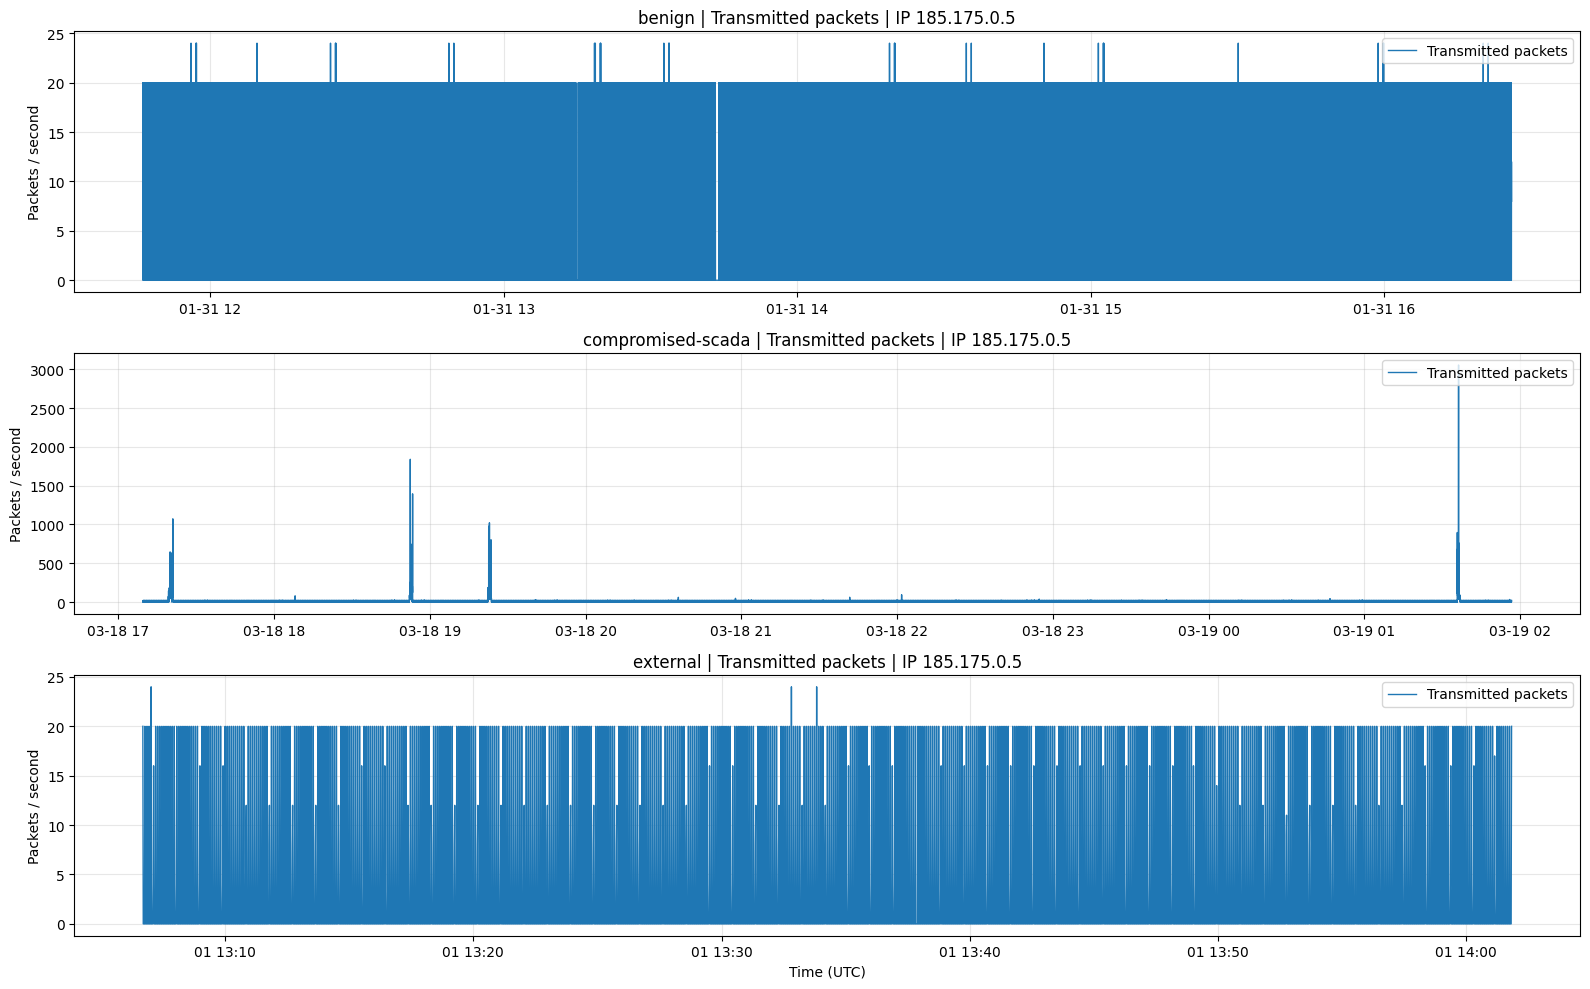

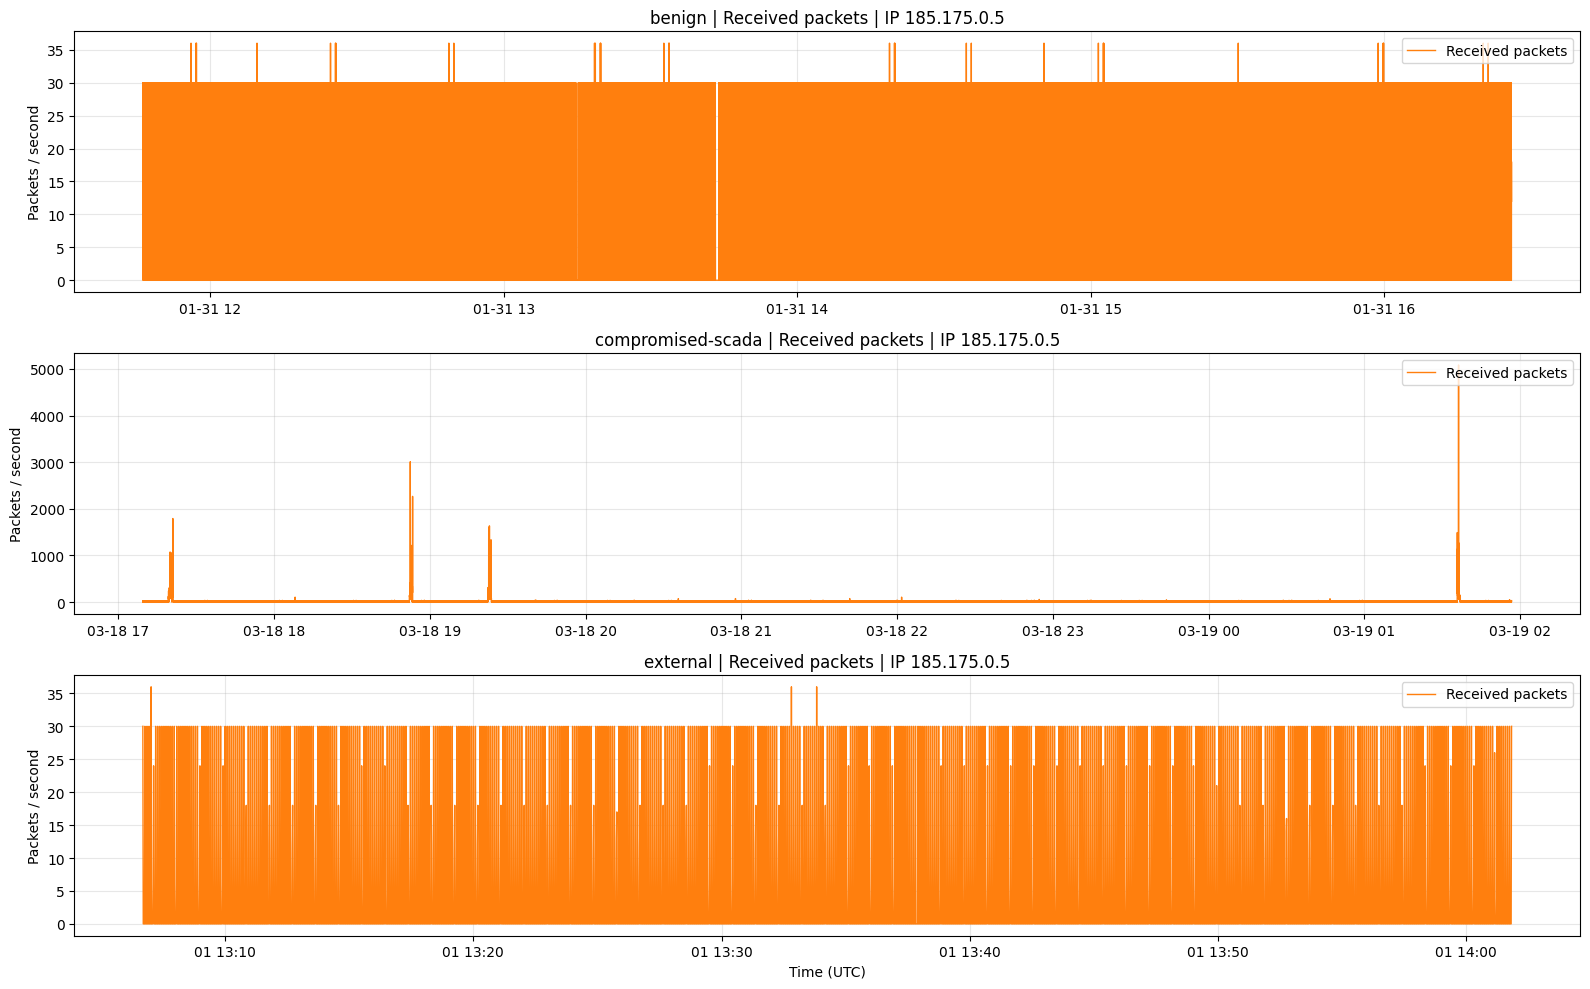

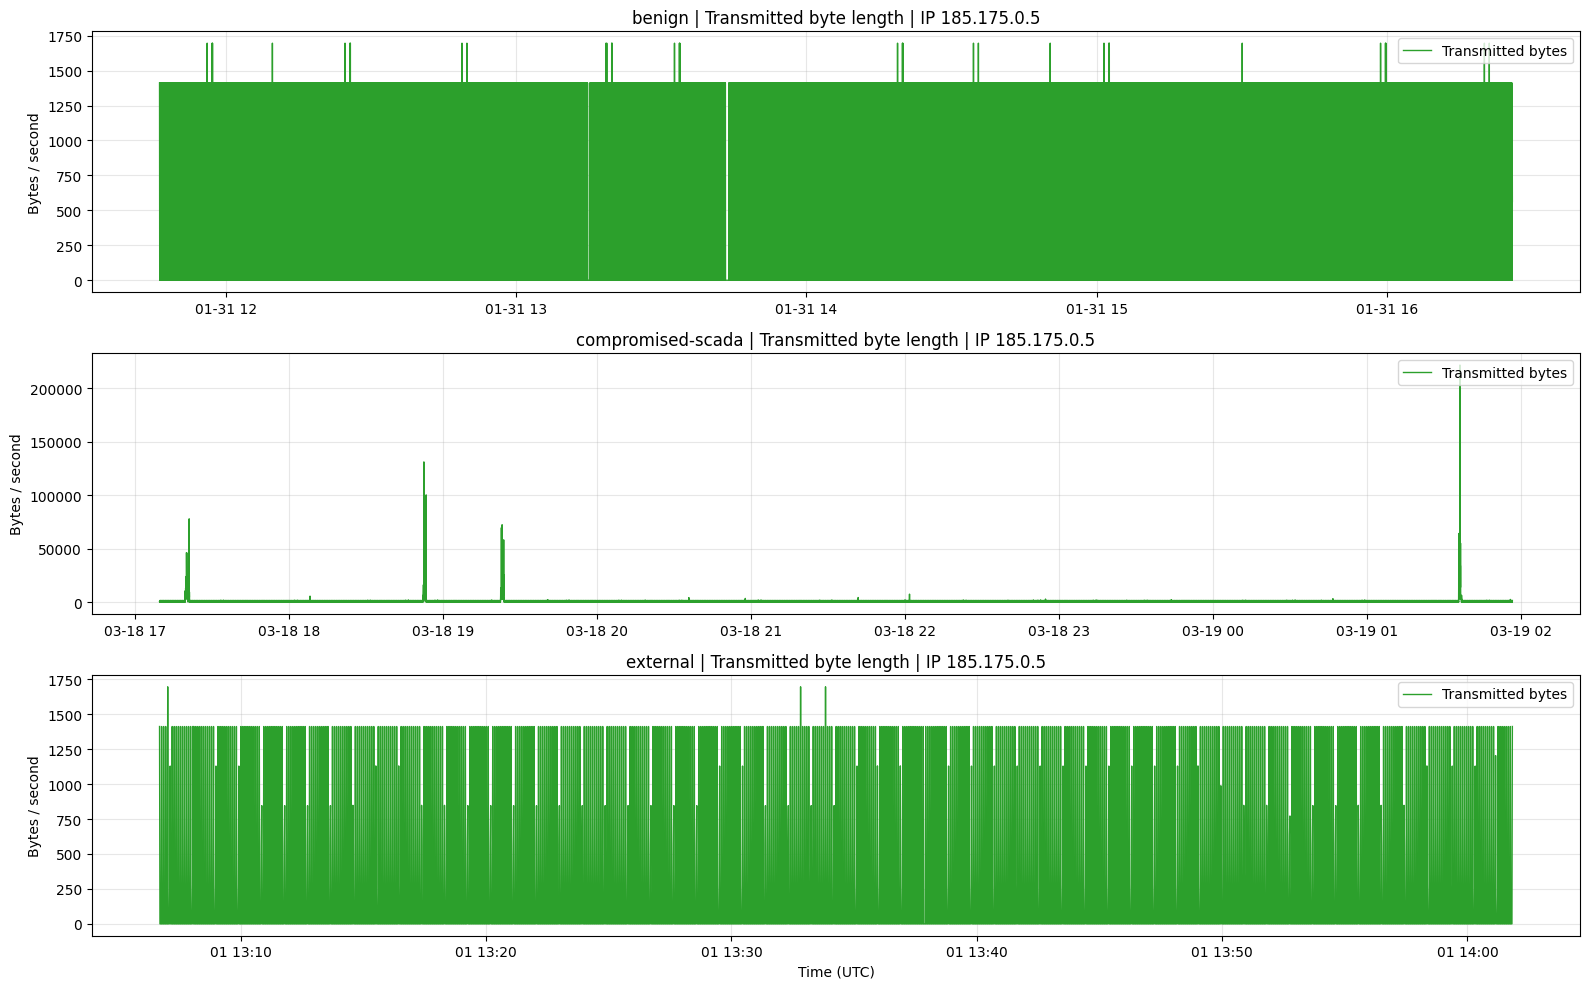

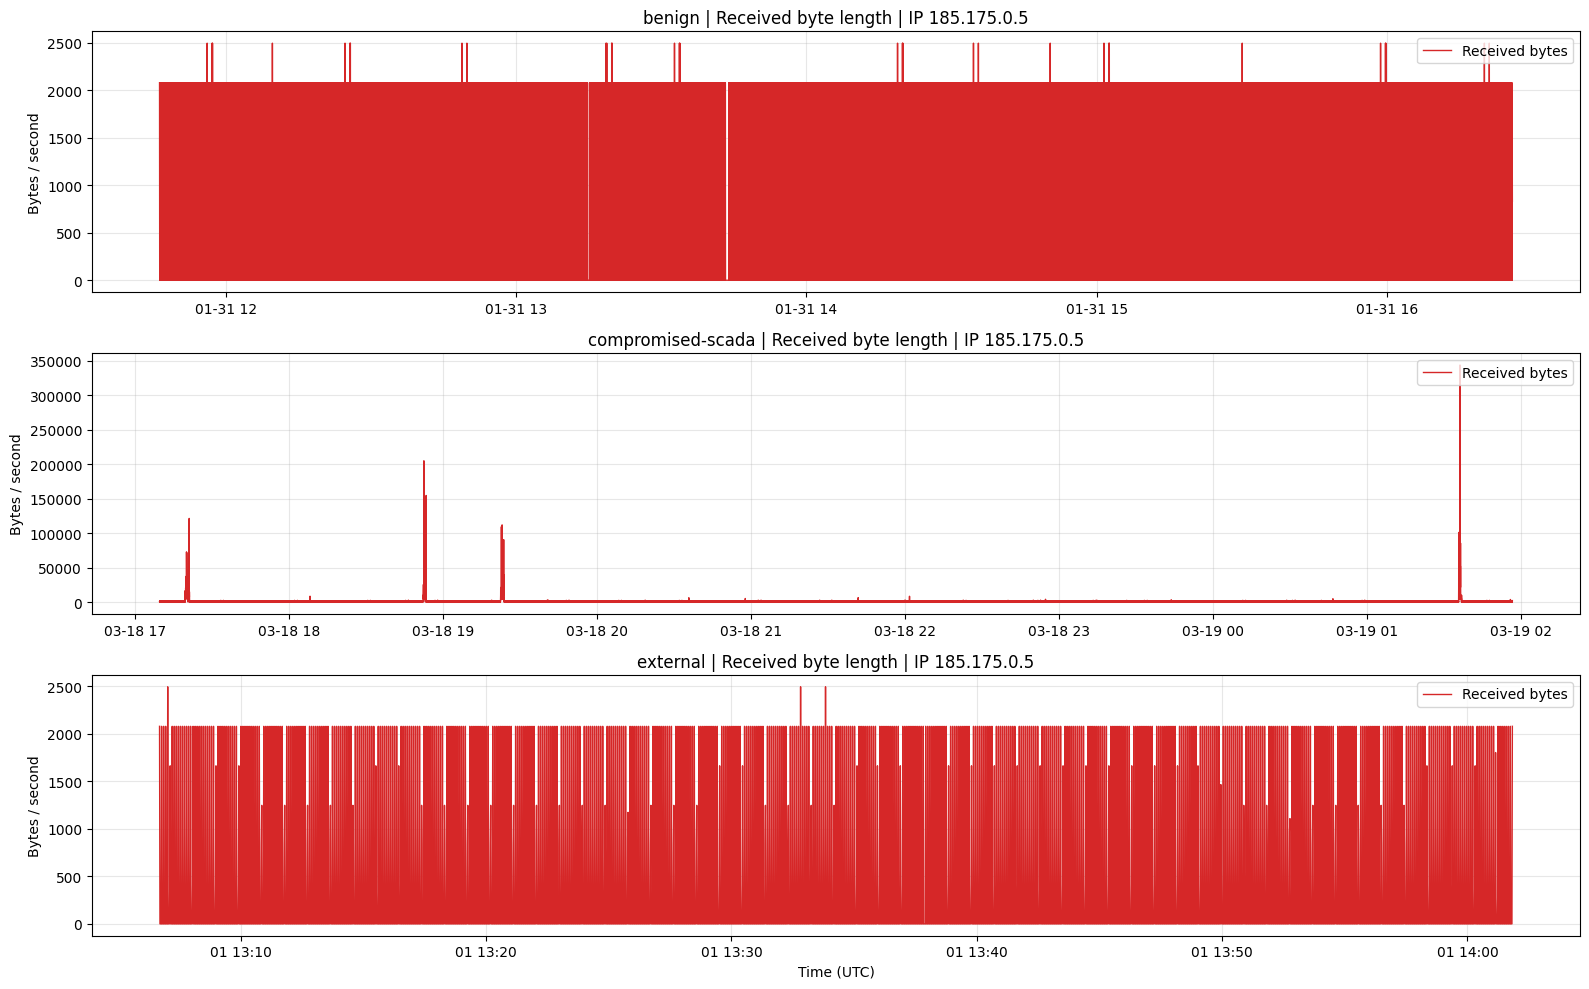

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

TARGET_IP = "185.175.0.5"

# Restrict collection to only the requested train CSV files.
CASE_FILES = {
    "benign": "../train/benign_nw_analysis.csv",
    "compromised-scada": "../train/cscada_attack_ssw_analysis.csv",
    "external": "../train/ext_attack_nw_analysis.csv",
}


def to_second_bucket(ts_series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(ts_series):
        return pd.to_datetime(ts_series, unit="s", utc=True, errors="coerce").dt.floor("1s")
    return pd.to_datetime(ts_series, utc=True, errors="coerce").dt.floor("1s")


def packet_and_byte_rate_from_csv(csv_path: str, target_ip: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    required_cols = {"frame.time_epoch", "frame.len", "ip.src", "ip.dst"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path} missing required columns: {sorted(missing)}")

    sec = to_second_bucket(df["frame.time_epoch"])
    frame_len = pd.to_numeric(df["frame.len"], errors="coerce").fillna(0.0)

    tx_mask = (df["ip.src"].astype(str) == target_ip) & sec.notna()
    rx_mask = (df["ip.dst"].astype(str) == target_ip) & sec.notna()

    tx_pkt = sec[tx_mask].value_counts().sort_index()
    rx_pkt = sec[rx_mask].value_counts().sort_index()

    tx_bytes = frame_len[tx_mask].groupby(sec[tx_mask]).sum().sort_index()
    rx_bytes = frame_len[rx_mask].groupby(sec[rx_mask]).sum().sort_index()

    if tx_pkt.empty and rx_pkt.empty and tx_bytes.empty and rx_bytes.empty:
        return pd.DataFrame(columns=["tx_count", "rx_count", "tx_bytes", "rx_bytes"])

    start_ts = min(
        tx_pkt.index.min() if not tx_pkt.empty else pd.Timestamp.max,
        rx_pkt.index.min() if not rx_pkt.empty else pd.Timestamp.max,
        tx_bytes.index.min() if not tx_bytes.empty else pd.Timestamp.max,
        rx_bytes.index.min() if not rx_bytes.empty else pd.Timestamp.max,
    )
    end_ts = max(
        tx_pkt.index.max() if not tx_pkt.empty else pd.Timestamp.min,
        rx_pkt.index.max() if not rx_pkt.empty else pd.Timestamp.min,
        tx_bytes.index.max() if not tx_bytes.empty else pd.Timestamp.min,
        rx_bytes.index.max() if not rx_bytes.empty else pd.Timestamp.min,
    )

    idx = pd.date_range(start=start_ts, end=end_ts, freq="1s", tz="UTC")

    out = pd.DataFrame(index=idx)
    out["tx_count"] = tx_pkt.reindex(idx, fill_value=0).to_numpy()
    out["rx_count"] = rx_pkt.reindex(idx, fill_value=0).to_numpy()
    out["tx_bytes"] = tx_bytes.reindex(idx, fill_value=0).to_numpy()
    out["rx_bytes"] = rx_bytes.reindex(idx, fill_value=0).to_numpy()
    return out


case_series = {}
for case_name, csv_path in CASE_FILES.items():
    series_df = packet_and_byte_rate_from_csv(csv_path, TARGET_IP)
    case_series[case_name] = series_df
    print(f"{case_name}: {len(series_df)} one-second bins from {csv_path}")

print("\nStatistical description (packet and byte rates)")
for case_name, df_series in case_series.items():
    print(f"\n{case_name} | IP {TARGET_IP}")
    if df_series.empty:
        print("No matching packets found.")
        continue
    print(df_series[["tx_count", "rx_count", "tx_bytes", "rx_bytes"]].describe())


# Plot transmitted packet counts.
fig_tx_pkt, axes_tx_pkt = plt.subplots(nrows=3, ncols=1, figsize=(16, 10), sharex=False)
for ax, case_name in zip(axes_tx_pkt, CASE_FILES.keys()):
    df_series = case_series[case_name]
    if df_series.empty:
        ax.set_title(f"{case_name} | TX packets | IP {TARGET_IP} | no matching packets found")
        ax.grid(True, alpha=0.3)
        continue

    ax.plot(df_series.index, df_series["tx_count"], label="Transmitted packets", linewidth=1.0, color="tab:blue")
    ax.set_title(f"{case_name} | Transmitted packets | IP {TARGET_IP}")
    ax.set_ylabel("Packets / second")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes_tx_pkt[-1].set_xlabel("Time (UTC)")
plt.tight_layout()
plt.show()


# Plot received packet counts.
fig_rx_pkt, axes_rx_pkt = plt.subplots(nrows=3, ncols=1, figsize=(16, 10), sharex=False)
for ax, case_name in zip(axes_rx_pkt, CASE_FILES.keys()):
    df_series = case_series[case_name]
    if df_series.empty:
        ax.set_title(f"{case_name} | RX packets | IP {TARGET_IP} | no matching packets found")
        ax.grid(True, alpha=0.3)
        continue

    ax.plot(df_series.index, df_series["rx_count"], label="Received packets", linewidth=1.0, color="tab:orange")
    ax.set_title(f"{case_name} | Received packets | IP {TARGET_IP}")
    ax.set_ylabel("Packets / second")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes_rx_pkt[-1].set_xlabel("Time (UTC)")
plt.tight_layout()
plt.show()


# Plot transmitted byte lengths.
fig_tx_bytes, axes_tx_bytes = plt.subplots(nrows=3, ncols=1, figsize=(16, 10), sharex=False)
for ax, case_name in zip(axes_tx_bytes, CASE_FILES.keys()):
    df_series = case_series[case_name]
    if df_series.empty:
        ax.set_title(f"{case_name} | TX bytes | IP {TARGET_IP} | no matching packets found")
        ax.grid(True, alpha=0.3)
        continue

    ax.plot(df_series.index, df_series["tx_bytes"], label="Transmitted bytes", linewidth=1.0, color="tab:green")
    ax.set_title(f"{case_name} | Transmitted byte length | IP {TARGET_IP}")
    ax.set_ylabel("Bytes / second")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes_tx_bytes[-1].set_xlabel("Time (UTC)")
plt.tight_layout()
plt.show()


# Plot received byte lengths.
fig_rx_bytes, axes_rx_bytes = plt.subplots(nrows=3, ncols=1, figsize=(16, 10), sharex=False)
for ax, case_name in zip(axes_rx_bytes, CASE_FILES.keys()):
    df_series = case_series[case_name]
    if df_series.empty:
        ax.set_title(f"{case_name} | RX bytes | IP {TARGET_IP} | no matching packets found")
        ax.grid(True, alpha=0.3)
        continue

    ax.plot(df_series.index, df_series["rx_bytes"], label="Received bytes", linewidth=1.0, color="tab:red")
    ax.set_title(f"{case_name} | Received byte length | IP {TARGET_IP}")
    ax.set_ylabel("Bytes / second")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes_rx_bytes[-1].set_xlabel("Time (UTC)")
plt.tight_layout()
plt.show()